<a href="https://colab.research.google.com/github/DABMASTER-Brought-me-into-this/ZeroToHeroColabCollection/blob/main/recall_micrograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline
# Line 4 Essentially forces graphs to be displayed in the same cell

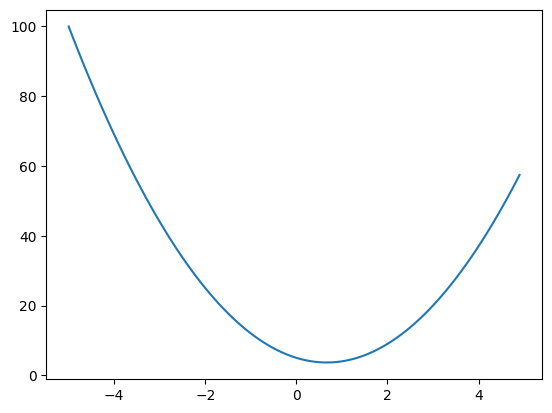

In [ ]:
# Function 1
def f(x):
  return 3*x**2 - 4*x + 5

xs = np.arange(-5, 5, 0.1) # This function kinda is like range.
ys = f(xs)
plt.plot(xs, ys)

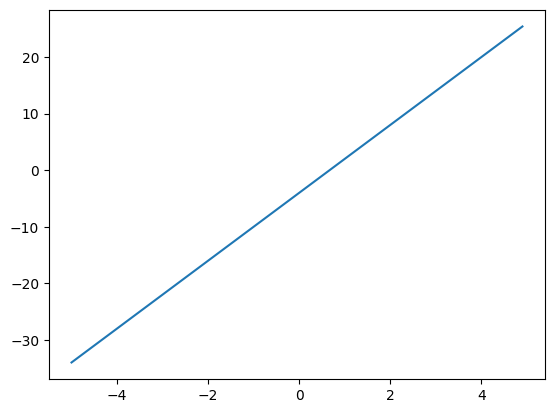

In [ ]:
# Derivative Function
def derivative(func, val):
  return (func(val + 0.0001) - func(val))/0.0001

ds = derivative(f, xs)
plt.plot(xs, ds)

In [ ]:
# More complication
# Inputs
a = -3
b = 2
c = 10

# Function
def d(a, b, c):
  return a*b + c

# Derivative
print("Derivative of d with respect to a", derivative(lambda x: d(x, b, c), a))
print("Derivative of d with respect to b", derivative(lambda x: d(a, x, c), b))
print("Derivative of d with respect to c", derivative(lambda x: d(a, b, x), c))

Derivative of d with respect to a 2.0000000000042206
Derivative of d with respect to b -3.000000000010772
Derivative of d with respect to c 0.9999999999976694


In [ ]:
class Value:
  def __init__(self, data, _children = (), _op = '', label = ''):
    self.data = data
    self.label = label
    self._prev = _children # set() just removes duplicates
    # I will temp remove set() to attempt to make the map he made in his video
    self.grad = 0.0
    self._op = _op
    self._backward = lambda : None


  def __repr__(self):
    return f'Value(data={self.data})'


  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += out.grad
      other.grad += out.grad

    out._backward = _backward
    return out


  def __radd__(self, other):
    return self + other


  def __sub__(self,other):
    return self + (-other)


  def __rsub__(self, other):
    return other + (-self)


  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    out._backward = _backward
    return out


  def __rmul__(self, other):
    return self * other


  def __truediv__(self, other):
    return self * (other ** -1)


  def __rtruediv__(self, other):
    return (self ** -1) * other


  def __pow__(self,other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data ** other.data, (self,other), "**")

    def _backward():
      self.grad += (other.data * self.data ** (other.data - 1)) * out.grad
      if self.data > 0:
        other.grad += np.log(self.data) * self.data ** other.data * out.grad
      else:
        other.grad += 0

    out._backward = _backward
    return out


  def __rpow__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    return self ** other


  def tanh(self):
    out = Value(np.tanh(self.data), (self,), "tanh")

    def _backward():
      self.grad += (1 - np.tanh(self.data) ** 2) * out.grad

    out._backward = _backward
    return out


  def __neg__(self):
    return self*-1


  def backward(self): # Cheat Here
    topo = []
    visited = set()

    def build_topo(v):
      if v in visited:
        return
      visited.add(v)
      for child in v._prev:
        build_topo(child)
      topo.append(v)

    build_topo(self)

    self.grad = 1.0 # Initialize gradient of the output node
    for node in reversed(topo):
      node._backward()


def dags(num: Value, depth = 0):
  if depth == 0:
    print(f"[{num.label} | data = {num.data} | grad = {num.grad}] (op: {num._op})\n")
  if len(num._prev) == 2:
    print("│   " * depth + f"├── [{num._prev[0].label} | data = {num._prev[0].data} | grad = {num._prev[0].grad}] {f'(op: {num._prev[0]._op})' if num._prev[0]._op else ''}\n")
    dags(num._prev[0], depth+1)
    print("│   " * depth + f"└── [{num._prev[1].label} | data = {num._prev[1].data} | grad = {num._prev[1].grad}] {f'(op: {num._prev[1]._op})' if num._prev[1]._op else ''}\n")
    dags(num._prev[1], depth+1)
  elif len(num._prev) == 1:
    print("│   " * depth + f"└── [{num._prev[0].label} | data = {num._prev[0].data} | grad = {num._prev[0].grad}] {f'(op: {num._prev[0]._op})' if num._prev[0]._op else ''}\n")
    dags(num._prev[0], depth+1)
  else:
    pass

In [ ]:
# Neural Net
# Inputs
# Fix: Use label= keyword argument so the string isn't treated as a child node
x1, x2 = Value(2.0, label="x1"), Value(0, label="x2")
# Weights
w1, w2 = Value(-3, label="w1"), Value(1, label="w2")
# Bias
b = Value(6.7, label="b")

x1w1 = x1*w1;x1w1.label = "x1w1"
x2w2 = x2*w2;x2w2.label = "x2w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1 + x2w2"
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [ ]:
dags(o)

[o | data = 0.6043677771171636 | grad = 0.0] (op: tanh)

└── [n | data = 0.7000000000000002 | grad = 0.0] (op: +)

│   ├── [x1w1 + x2w2 | data = -6.0 | grad = 0.0] (op: +)

│   │   ├── [x1w1 | data = -6.0 | grad = 0.0] (op: *)

│   │   │   ├── [x1 | data = 2.0 | grad = 0.0] 

│   │   │   └── [w1 | data = -3 | grad = 0.0] 

│   │   └── [x2w2 | data = 0 | grad = 0.0] (op: *)

│   │   │   ├── [x2 | data = 0 | grad = 0.0] 

│   │   │   └── [w2 | data = 1 | grad = 0.0] 

│   └── [b | data = 6.7 | grad = 0.0] 



In [ ]:
class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1, 1))

  def __call__(self, x):
    act = sum(x1*w1 for x1, w1 in zip(self.w, x)) + self.b
    out = act.tanh()
    return out


class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)] # Cheat here


  def __call__(self, x):
    outs = [n(x) for n in self.neurons] # Cheat Here
    return outs if len(outs) > 1 else outs[0]


class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], (sz[i+1])) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x


x = [1.0, 3.0, 2.0]
n = MLP(3, [4,4,1])
o = n(x)
o.backward()
dags(o)

[ | data = 0.8085208093474626 | grad = 1.0] (op: tanh)

└── [ | data = 1.12274271001114 | grad = 0.346294100852124] (op: +)

│   ├── [ | data = 0.1338020071146418 | grad = 0.346294100852124] (op: +)

│   │   ├── [ | data = 0.45967535079299104 | grad = 0.346294100852124] (op: +)

│   │   │   ├── [ | data = 0.5987445552041134 | grad = 0.346294100852124] (op: +)

│   │   │   │   ├── [ | data = -0.024567563686912788 | grad = 0.346294100852124] (op: +)

│   │   │   │   │   ├── [ | data = -0.024567563686912788 | grad = 0.346294100852124] (op: *)

│   │   │   │   │   │   ├── [ | data = 0.13187057815260617 | grad = -0.06451478787968459] 

│   │   │   │   │   │   └── [ | data = -0.18630056856565969 | grad = 0.045666003290206494] (op: tanh)

│   │   │   │   │   │   │   └── [ | data = -0.18850196449108197 | grad = 0.04408103213022467] (op: +)

│   │   │   │   │   │   │   │   ├── [ | data = 0.2648659231930374 | grad = 0.04408103213022467] (op: +)

│   │   │   │   │   │   │   │   │   ├── [ | data =